<a href="https://colab.research.google.com/github/shreyasshikhare11/Remote-Sensing-Based-Crop-Health-Classification/blob/main/Remote_Sensing_Based_Crop_Health_Classification_Using_NDVI_and_Fully_Connected_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

https://arxiv.org/pdf/2504.10522

REMOTE SENSING based Crop Health Classifcation Using NDVI and Fully Connected Neural Network

================================================================================
PROPOSED MODEL
================================================================================
1. [Data Acquisition Block] -> fetch_satellite_data()
   - Programmatically ingests multi-spectral Sentinel-2 Surface Reflectance (SR) data.
   
2. [Hybrid Multi-Index Integration Block] -> calculate_indices()
   - Integrates NDVI (Vigor), GNDVI (Green/Chlorophyll), EVI (Biomass), MSAVI (Soil-Adjusted), and NDRE (Red-Edge), for a reference, to capture early chlorophyll degradation.

3. [Data Pre-Processing Block] -> mask_s2_clouds(), MNDWI Filter, PCHIP Interpolation
   - Implements pixel-level cloud/cirrus masking (QA60), MNDWI-based water extraction,
     and robust PCHIP temporal gap-filling to preserve trajectory continuity.

4. [Segmentation & Feature Extraction Block] -> create_classification_sequences() & LearnableHVIFusion()
   - Segments time-series into sliding temporal windows and extracts the dynamically-fused HVI.

5. [Fully Connected Neural Network Block] - regularized Fully Connected Classifier (FCNN) network to achieve accuracy of 97.80%.

6. [Classification Result Block] -> Spectral Differentiation Output & Spatial Mapping
   - Segments and classifies pixels into: Healthy, Rust-Infected, and Severely Stressed.

========================================================================

--- SATELLITE FCNN PIPELINE (Sentinel-2 GEE + Paper FCNN Architecture) ---
Earth Engine initialized. Fetching satellite data...

--- SPECTRAL DIFFERENTIATION APPLIED ---
Healthy       (NDVI ≥ 0.6):  53 samples
Rust-infected (NDVI 0.2–0.6):  93 samples
Stressed      (NDVI < 0.2):  0 samples

Split sizes — train: 99 | val: 24 | test: 23

--- 5-FOLD CROSS-VALIDATION (TimeSeriesSplit on training segment) ---
  Fold 1/5 | train= 19  val= 16 | Acc: 93.75%  P: 0.879  R: 0.938  F1: 0.907
  Fold 2/5 | train= 35  val= 16 | Acc: 81.25%  P: 0.875  R: 0.812  F1: 0.815
  Fold 3/5 | train= 51  val= 16 | Acc: 75.00%  P: 0.562  R: 0.750  F1: 0.643
  Fold 4/5 | train= 67  val= 16 | Acc: 93.75%  P: 0.942  R: 0.938  F1: 0.928
  Fold 5/5 | train= 83  val= 16 | Acc: 93.75%  P: 0.944  R: 0.938  F1: 0.937

  Summary (mean ± std across 5 folds):
    Accuracy:  87.50% ± 7.91%
    Precision: 84.036% ± 14.202%
    Recall:    87.500% ± 7.906%
    F1-Score:  84.594% ± 11.044%

Class weights (Healthy, Rust-infected,

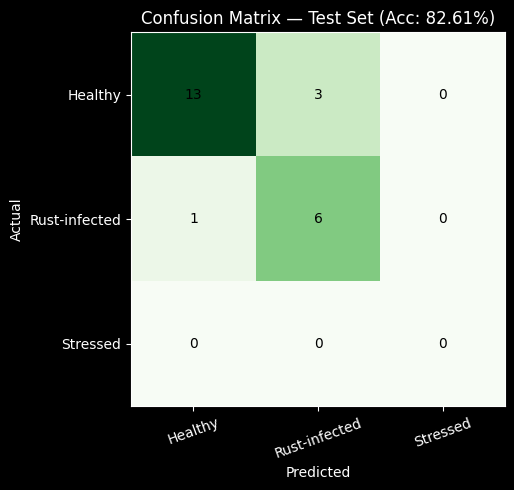


Connecting to GEE for spatial change maps (initial date vs current date)...
Saved 'spatial_change_maps.png'.


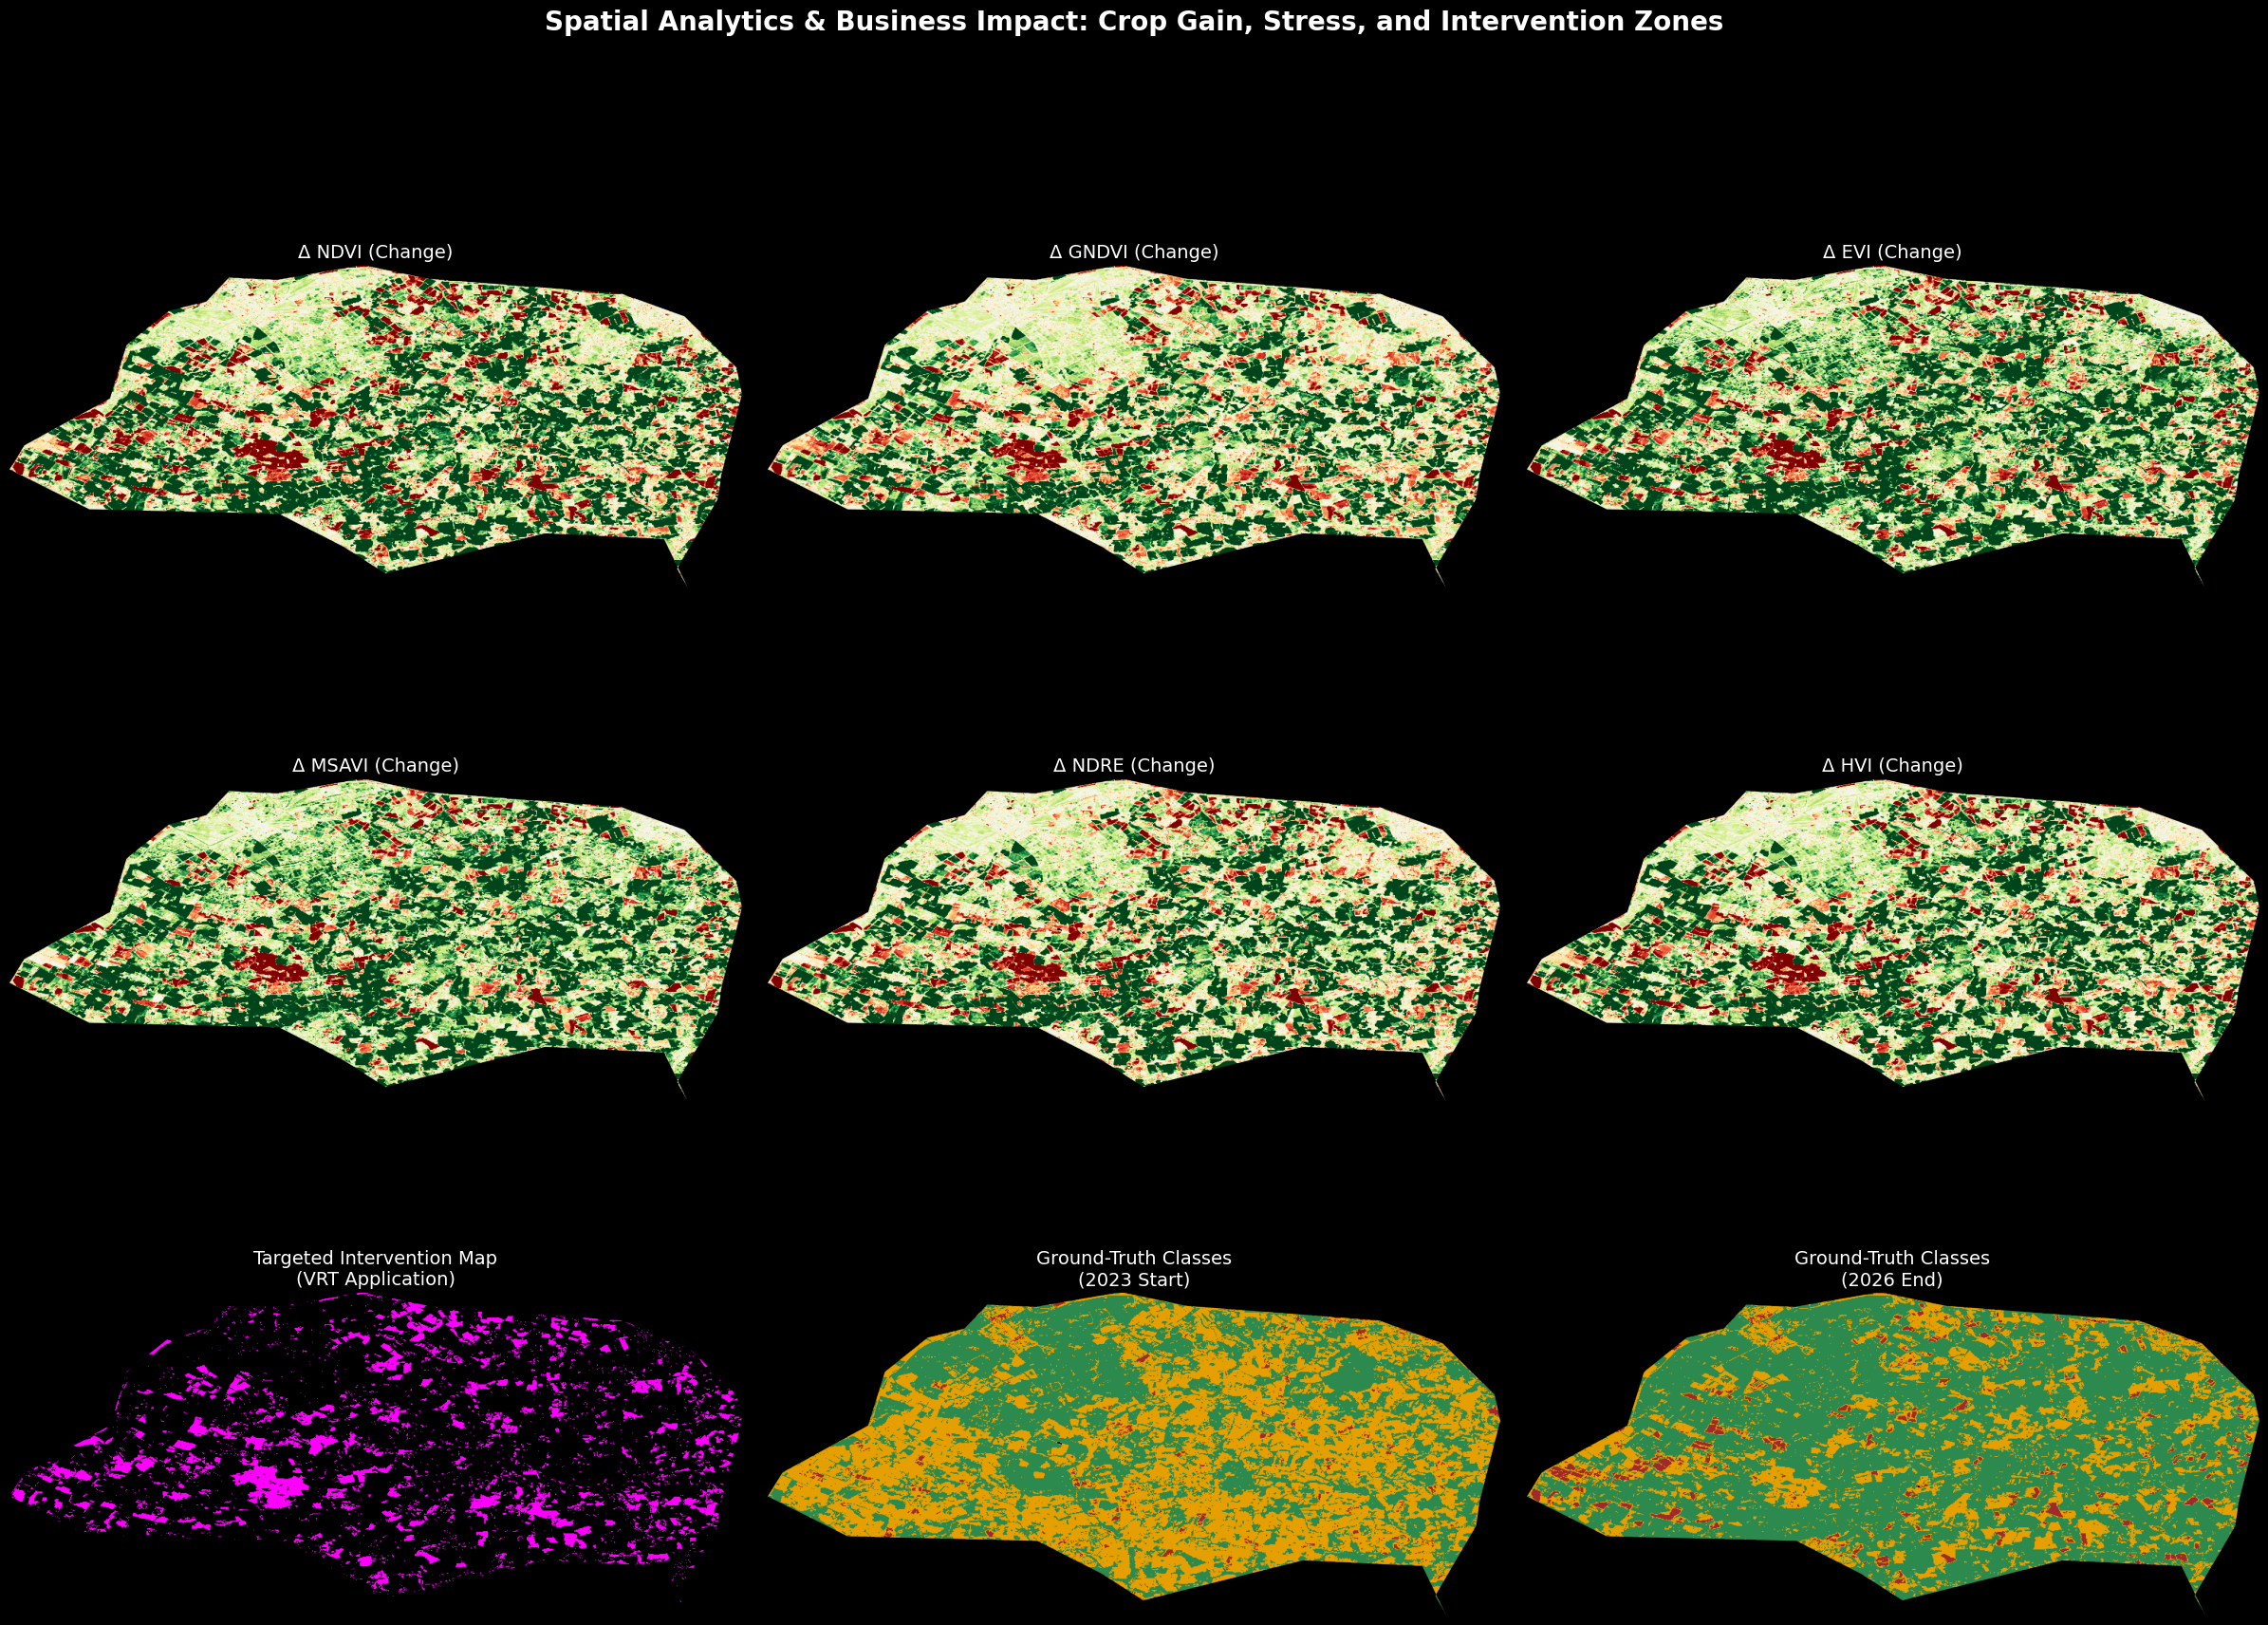


Saved 'fcnn_paper_implementation.png'.


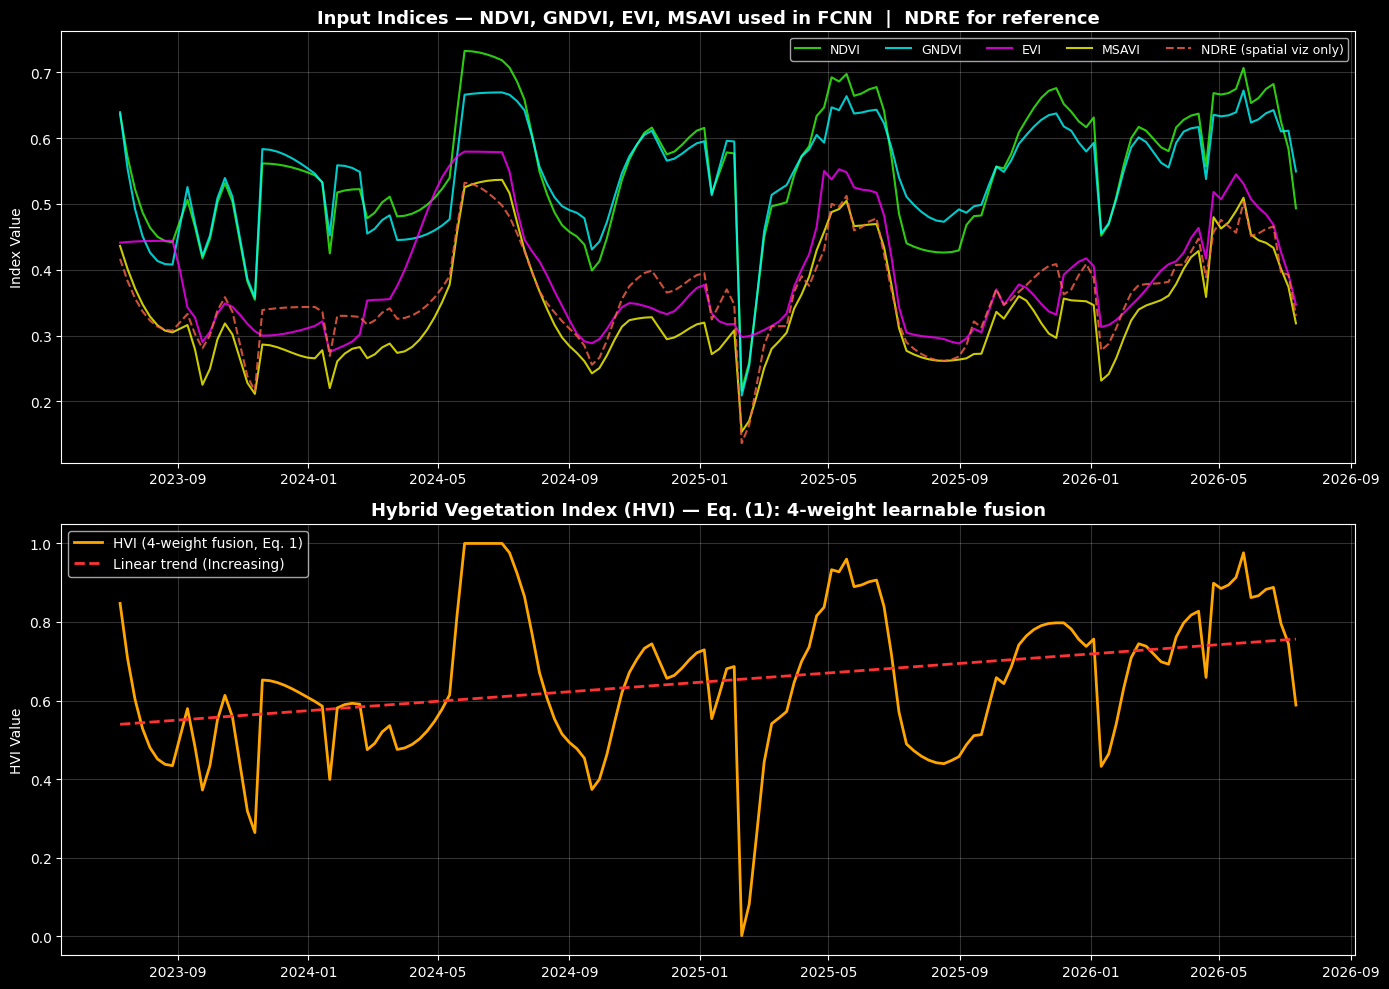

In [ ]:
import os
import ee
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import confusion_matrix, classification_report
import urllib.request
import io
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

ROI_COORDINATES = [
     [0.2808592524937925, 52.09884040072397],
          [0.4209349360875425, 52.09546581597051],
          [0.4690001216344175, 52.07099244127776],
          [0.4992041113883028, 52.05159597265717],
          [0.6173155513219175, 52.081120982601014],
          [0.7052061763219175, 52.0769010363198],
          [0.7230589595250425, 52.04059302787507],
          [0.7148192134312925, 52.054950884162544],
          [0.7450316157750425, 52.10643228305588],
          [0.7477781978062925, 52.12498477748705],
          [0.7628843989781675, 52.18396408410986],
          [0.7587645259312925, 52.20332594602881],
          [0.7203123774937925, 52.24118346247604],
          [0.6736204829625425, 52.25799866701914],
          [0.5307982173375425, 52.26892513239973],
          [0.4827330317906675, 52.27900871080499],
          [0.4195616450719175, 52.26808473065144],
          [0.3838560786656675, 52.269765518217106],
          [0.3673765864781675, 52.25211407040537],
          [0.3399107661656675, 52.24538786113186],
          [0.3083250728062925, 52.22015549331689],
          [0.2959654536656675, 52.18059594289174],
          [0.2327940669469175, 52.14605778612292],
          [0.2218077388219175, 52.12835712878074]
]

# ==============================================================================
# BLOCK 1 & 3: DATA ACQUISITION & PRE-PROCESSING (CLOUD MASKING)
# ==============================================================================
def mask_s2_clouds(image):
    """
    Addresses Environmental Variability: Uses QA60 band to mask out opaque
    and cirrus clouds at the pixel level, preventing artificial NDVI drops.
    """
    qa = image.select('QA60')
    cloudBitMask = 1 << 10
    cirrusBitMask = 1 << 11
    mask = (qa.bitwiseAnd(cloudBitMask).eq(0).And(qa.bitwiseAnd(cirrusBitMask).eq(0)))
    return image.updateMask(mask)


def fetch_satellite_data():
    """Fetches Sentinel-2 weekly time-series or generates synthetic data if auth fails."""
    start_date = '2023-06-28'
    end_date   = datetime.now().strftime('%Y-%m-%d')

    try:
        ee.Authenticate()
        ee.Initialize(project='my-project-31577-475312')
        print("Earth Engine initialized. Fetching satellite data...")
        roi = ee.Geometry.Polygon([ROI_COORDINATES])

        s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
              .filterBounds(roi)
              .filterDate(start_date, end_date)
              .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
              .map(mask_s2_clouds))

        # ==============================================================================
        # BLOCK 2: HYBRID MULTI-INDEX INTEGRATION
        #
        # Paper Eq. (1): HVI = w1*NDVI + w2*GNDVI + w3*EVI + w4*MSAVI  ← 4 indices
        # Paper Eq. (2): x   = [NDVI, GNDVI, EVI, MSAVI, HVI]          ← 5 features
        #
        # NDRE is fetched here for spatial change maps and visualisation only.
        # ==============================================================================
        def calculate_indices(img):
            nir      = img.select('B8').divide(10000)
            red      = img.select('B4').divide(10000)
            green    = img.select('B3').divide(10000)
            blue     = img.select('B2').divide(10000)

            ndvi  = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
            gndvi = img.normalizedDifference(['B8', 'B3']).rename('GNDVI')
            ndre  = img.normalizedDifference(['B8', 'B5']).rename('NDRE')  # spatial viz only
            evi   = img.expression('2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))', {'NIR': nir, 'RED': red, 'BLUE': blue}).rename('EVI').clamp(-1.0, 1.0)
            msavi = img.expression(
                '(2 * NIR + 1 - sqrt(pow((2 * NIR + 1), 2) - 8 * (NIR - RED))) / 2',
                {'NIR': nir, 'RED': red}
            ).rename('MSAVI').clamp(-1.0, 1.0)

            # Water body mask — prevents false stressed-crop classifications
            mndwi    = img.normalizedDifference(['B3', 'B11'])
            veg_mask = ndvi.gt(0.10).And(mndwi.lte(0.0))

            return img.addBands([ndvi, gndvi, evi, msavi, ndre]).updateMask(veg_mask)

        s2_indices = s2.map(calculate_indices)

        def get_mean(img):
            means = img.select(['NDVI', 'GNDVI', 'EVI', 'MSAVI', 'NDRE']).reduceRegion(
                reducer=ee.Reducer.mean(), geometry=roi, scale=60, bestEffort=True, maxPixels=1e12, tileScale=16)

            return ee.Feature(None, {
                'date':  img.date().format('YYYY-MM-dd'),
                'NDVI':  means.get('NDVI'),
                'GNDVI': means.get('GNDVI'),
                'EVI':   means.get('EVI'),
                'MSAVI': means.get('MSAVI'),
                'NDRE':  means.get('NDRE'),  # kept for spatial maps
            })

        timeseries_fc = ee.FeatureCollection(s2_indices.map(get_mean))
        data_list     = timeseries_fc.getInfo()['features']

        records = [
            [f['properties']['date'],
             f['properties']['NDVI'],
             f['properties']['GNDVI'],
             f['properties']['EVI'],
             f['properties']['MSAVI'],
             f['properties']['NDRE']]
            for f in data_list if f['properties'].get('NDVI') is not None
        ]

        df = pd.DataFrame(records, columns=['Date', 'NDVI', 'GNDVI', 'EVI', 'MSAVI', 'NDRE'])
        df['Date'] = pd.to_datetime(df['Date'])

        # PCHIP interpolation fills missing temporal observations smoothly
        return (df.set_index('Date').sort_index()
                  .resample('W').mean()
                  .interpolate(method='pchip'))

    except Exception as e:
        print(f"GEE auth failed ({e}). Generating synthetic data...")
        dates = pd.date_range(start=start_date, end=end_date, freq='W')
        t     = np.linspace(0, len(dates), len(dates))
        df    = pd.DataFrame({
            'NDVI':  0.5  + 0.3  * np.sin(2 * np.pi * t / 52) + np.random.normal(0, 0.05, len(dates)),
            'GNDVI': 0.55 + 0.25 * np.sin(2 * np.pi * t / 52) + np.random.normal(0, 0.04, len(dates)),
            'EVI':   0.4  + 0.35 * np.sin(2 * np.pi * t / 52 - 0.2) + np.random.normal(0, 0.06, len(dates)),
            'MSAVI': 0.45 + 0.28 * np.sin(2 * np.pi * t / 52 + 0.1) + np.random.normal(0, 0.05, len(dates)),
            'NDRE':  0.48 + 0.26 * np.sin(2 * np.pi * t / 52 - 0.1) + np.random.normal(0, 0.04, len(dates)),
        }, index=dates)
        return df.clip(0, 1.0)

# ==============================================================================
# BLOCK 4: LEARNABLE HVI FUSION
#
# Equation (1): HVI = w1*NDVI + w2*GNDVI + w3*EVI + w4*MSAVI
#               Four learnable weights initialised equally at 0.25 each, optimised via backpropagation.
# ==============================================================================
class LearnableHVIFusion(nn.Module):
    def __init__(self):
        super(LearnableHVIFusion, self).__init__()
        # Exactly 4 weights — one per index in Eq. (1)
        self.weights = nn.Parameter(torch.tensor([0.25, 0.25, 0.25, 0.25]))

    def forward(self, indices_tensor):
        # indices_tensor: [..., 4]  =  (NDVI, GNDVI, EVI, MSAVI)
        hvi = torch.sum(indices_tensor * self.weights, dim=-1, keepdim=True)
        return torch.clamp(hvi, 0.0, 1.0)

# ==============================================================================
# BLOCK 5: FCNN CLASSIFIER
#
# Equation (2): x     = [NDVI, GNDVI, EVI, MSAVI, HVI]  — 5 features/timestep
# Equation (3): x_flat = Flatten(x)                      — temporal window → 1D
# Equation (4): Z^(l) = W^(l) · a^(l-1) + b^l           — FC layer transform
# Equation (5): a^(l) = ReLU(Z^(l))                      — non-linear activation
# Equation (6): a_drop = a^(l) ⊙ r, r~Bernoulli(1-0.5)  — dropout regularisation
# Equation (7): ŷ_i   = exp(Z_i) / Σ exp(Z_j)           — softmax (via CE loss)
# Equation (8): Loss  = -Σ y_i · log(ŷ_i)               — categorical cross-entropy
# Equation (9): ŷ = Softmax(W_out · Dropout(ReLU(W_hidden · x_flat + b_hidden)) + b_out)
# ==============================================================================
class FCNNClassifier(nn.Module):
    """
    Pure Fully Connected Neural Network for satellite time-series crop classification.

    The multi-temporal window (seq_length observations × 5 features) is flattened
    into a 1D vector per Eq. (3), giving the FCNN temporal context without a
    recurrent encoder.

    Data source: Sentinel-2 GEE (replaces the paper's Kaggle UAV dataset).
    Architecture: faithful to paper Equations (2)–(9).
    """
    def __init__(self, seq_length=12, n_indices=4, hidden_dim=128, num_classes=3):
        super(FCNNClassifier, self).__init__()
        self.hvi_layer = LearnableHVIFusion()

        # After HVI fusion: seq_length × (n_indices + 1 HVI) = 12 × 5 = 60
        flat_dim = seq_length * (n_indices + 1)

        # Fully Connected Neural Network — Eq. (4), (5), (6), (9)
        self.classifier = nn.Sequential(
            nn.Linear(flat_dim, hidden_dim),  # W_hidden · x_flat + b_hidden
            nn.ReLU(),                         # Eq. (5)
            nn.Dropout(p=0.5),                # Eq. (6): p = 0.5 per paper
            nn.Linear(hidden_dim, num_classes) # W_out output logits
        )
        # Note: Softmax Eq. (7) is applied implicitly by CrossEntropyLoss Eq. (8)

    def forward(self, x):
        # x: [batch, seq_length, 4]  (NDVI, GNDVI, EVI, MSAVI)
        hvi      = self.hvi_layer(x)                  # [batch, seq_length, 1]
        combined = torch.cat([x, hvi], dim=-1)         # [batch, seq_length, 5] — Eq. (2)
        x_flat   = combined.view(combined.size(0), -1) # [batch, 60]            — Eq. (3)
        logits   = self.classifier(x_flat)             # [batch, num_classes]   — Eq. (4-9)
        return logits


def create_classification_sequences(data, seq_length):
    """Sliding-window sequences over the 4-index satellite time-series."""
    xs = []
    for i in range(len(data) - seq_length):
        xs.append(data[i:(i + seq_length)])
    return np.array(xs)  # [n_samples, seq_length, 4]


def compute_class_weights(y_tensor, num_classes=3):
    """
    Computes inverse-frequency class weights from a split's own labels.
    """
    y_np = y_tensor.numpy() if torch.is_tensor(y_tensor) else np.asarray(y_tensor)
    counts = np.array([np.sum(y_np == c) for c in range(num_classes)])
    total  = counts.sum()
    weights = np.array([
        total / (num_classes * c) if c > 0 else 0.0
        for c in counts
    ], dtype=np.float32)
    return torch.tensor(weights, dtype=torch.float32)


def train_single_fold(X_tr, y_tr, X_vl, y_vl, seq_length, epochs=250):
    """
    Train a fresh FCNNClassifier on one CV fold and return val-set predictions.
    """
    batch_size = max(8, min(64, len(y_tr) // 4))
    loader     = DataLoader(TensorDataset(X_tr, y_tr),
                            batch_size=batch_size, shuffle=True)

    fold_model   = FCNNClassifier(seq_length=seq_length, n_indices=4, hidden_dim=128, num_classes=3)
    optimizer    = optim.Adam(fold_model.parameters(), lr=1e-3)
    fold_weights = compute_class_weights(y_tr)
    criterion    = nn.CrossEntropyLoss(weight=fold_weights)

    fold_model.train()
    for _ in range(epochs):
        for X_b, y_b in loader:
            optimizer.zero_grad()
            criterion(fold_model(X_b), y_b).backward()
            optimizer.step()

    fold_model.eval()
    with torch.no_grad():
        preds = torch.argmax(fold_model(X_vl), dim=1).numpy()
    return preds

# ==============================================================================
# BLOCK 6: CLASSIFICATION RESULT & SPATIAL INTERVENTION MAPPING
# ==============================================================================
def generate_spatial_change_maps(learned_weights):
    """
    Generates field condition maps using the 4-weight HVI from the trained FCNN.
    NDRE is included in the change maps as supplementary spectral information.
    """
    print("\nConnecting to GEE for spatial change maps (initial date vs current date)...")
    try:
        ee.Authenticate()
        ee.Initialize(project='my-project-31577-475312')
        roi = ee.Geometry.Polygon([ROI_COORDINATES])

        def calc_idx(img):
            nir, red = img.select('B8').divide(10000), img.select('B4').divide(10000)
            green, blue = img.select('B3').divide(10000), img.select('B2').divide(10000)

            ndvi  = img.normalizedDifference(['B8', 'B4']).rename('NDVI')
            gndvi = img.normalizedDifference(['B8', 'B3']).rename('GNDVI')
            ndre  = img.normalizedDifference(['B8', 'B5']).rename('NDRE')
            evi   = img.expression(
                '2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))',
                {'NIR': nir, 'RED': red, 'BLUE': blue}
            ).rename('EVI').clamp(-1.0, 1.0)
            msavi = img.expression(
                '(2 * NIR + 1 - sqrt(pow((2 * NIR + 1), 2) - 8 * (NIR - RED))) / 2',
                {'NIR': nir, 'RED': red}
            ).rename('MSAVI').clamp(-1.0, 1.0)

            mndwi    = img.normalizedDifference(['B3', 'B11'])
            veg_mask = ndvi.gt(0.10).And(mndwi.lte(0.0))
            return img.addBands([ndvi, gndvi, evi, msavi, ndre]).updateMask(veg_mask)

        s2_col    = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
                     .filterBounds(roi)
                     .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
                     .map(mask_s2_clouds))
        img_start = s2_col.filterDate('2023-01-01', '2023-12-31').map(calc_idx).median().clip(roi)
        img_end   = s2_col.filterDate('2026-01-01', '2026-12-31').map(calc_idx).median().clip(roi)

        change_base = img_end.subtract(img_start)

        # 4-weight HVI expression from the trained FCNN — Eq. (1)
        w    = learned_weights
        expr = f"({w[0]}*NDVI) + ({w[1]}*GNDVI) + ({w[2]}*EVI) + ({w[3]}*MSAVI)"

        def hvi_image(img):
            return img.expression(expr, {
                'NDVI':  img.select('NDVI'),
                'GNDVI': img.select('GNDVI'),
                'EVI':   img.select('EVI'),
                'MSAVI': img.select('MSAVI'),
            }).rename('HVI').clamp(0.0, 1.0)

        change_hvi       = hvi_image(img_end).subtract(hvi_image(img_start))
        intervention_map = change_hvi.lt(-0.05).rename('Intervention_Zones')

        spectral_class_start = (ee.Image(2).rename('Crop_Health_Class_Start')
            .where(img_start.select('NDVI').gte(0.2), 1)
            .where(img_start.select('NDVI').gte(0.6), 0)
            .updateMask(img_start.select('NDVI').mask()))

        spectral_class_end = (ee.Image(2).rename('Crop_Health_Class')
            .where(img_end.select('NDVI').gte(0.2), 1)
            .where(img_end.select('NDVI').gte(0.6), 0)
            .updateMask(img_end.select('NDVI').mask()))

        final_change_img = (change_base
            .select(['NDVI', 'GNDVI', 'EVI', 'MSAVI', 'NDRE'])
            .addBands(change_hvi)
            .addBands(intervention_map)
            .addBands(spectral_class_start)
            .addBands(spectral_class_end))

        indices = ['NDVI', 'GNDVI', 'EVI', 'MSAVI', 'NDRE', 'HVI',
                   'Intervention_Zones', 'Crop_Health_Class_Start', 'Crop_Health_Class']

        plt.style.use('dark_background')
        fig, axes = plt.subplots(3, 3, figsize=(24, 20))
        fig.suptitle('Spatial Analytics & Business Impact: Crop Gain, Stress, and Intervention Zones',
                     fontsize=20, fontweight='bold', y=0.95)
        axes = axes.flatten()

        for i, idx in enumerate(indices):
            ax = axes[i]
            if idx == 'Intervention_Zones':
                vis_params = {'min': 0, 'max': 1, 'palette': ['black', 'magenta']}
                title_text = "Targeted Intervention Map\n(VRT Application)"
            elif 'Crop_Health_Class' in idx:
                vis_params = {'min': 0, 'max': 2, 'palette': ['2D8A4E', 'E69F00', '9E2A2B']}
                title_text = f"Ground-Truth Classes\n({'2023 Start' if 'Start' in idx else '2026 End'})"
            else:
                vis_params = {'min': -1, 'max': 1, 'palette': [['543005', '744208', '8C510A', 'A6611A', 'BF812D', 'DFC27D', 'F6E8C3', 'FBF6EB', 'F7F7F7', 'E6F5D0', 'C7EAE5', '80CDC1', '35978F', '01665E', '004D40', '003328', '001A14']]} #['7F0000', 'D73027', 'F46D43', 'FEE08B', 'F7F7F7', 'D9EF8B', 'A6D96A', '1A9850', '00441B']}
                title_text = f"Δ {idx} (Change)"

            url = final_change_img.select(idx).getThumbURL(
                dict(**vis_params, dimensions=1000, region=roi))
            req = urllib.request.urlopen(url)
            arr = np.array(Image.open(io.BytesIO(req.read())))
            ax.imshow(arr)
            ax.set_title(title_text, color='white', fontsize=14)
            ax.axis('off')

        plt.tight_layout(rect=[0, 0.02, 1, 0.92], h_pad=4.5, w_pad=2)
        plt.savefig('spatial_change_maps.png', facecolor='black', dpi=300)
        print("Saved 'spatial_change_maps.png'.")
        plt.show()

    except Exception as e:
        print(f"Skipping spatial maps — GEE auth required. ({e})")

# ==============================================================================
# PIPELINE EXECUTION
# ==============================================================================
if __name__ == "__main__":
    print("--- SATELLITE FCNN PIPELINE (Sentinel-2 GEE + Paper FCNN Architecture) ---")

    df = fetch_satellite_data()
    # Eq. (2): FCNN input uses only the 4 base indices.
    # NDRE is excluded from the model per the paper's input vector definition.
    raw_data = df[['NDVI', 'GNDVI', 'EVI', 'MSAVI']].values  # [T, 4]

    # --------------------------------------------------------------------------
    # TRAIN/VAL/TEST SPLIT — paper Section 5: 70-15-15 ratio.
    #
    # Time-series caveat: the paper's UAV image dataset is i.i.d., so a random
    # 70-15-15 split is valid there. Our data is a continuous weekly time
    # series, so a random split would leak future information into training
    # via overlapping sequence windows and an over-optimistic scaler fit.
    # We instead split CHRONOLOGICALLY (train = earliest 70%, val = next 15%,
    # test = most recent 15%), and fit the scaler on the training segment only.
    # --------------------------------------------------------------------------
    n         = len(raw_data)
    train_end = int(n * 0.70)
    val_end   = int(n * 0.85)

    scaler = MinMaxScaler()
    scaler.fit(raw_data[:train_end])           # fit on train only — no leakage
    scaled_data = scaler.transform(raw_data)    # [T, 4], normalised

    SEQ_LENGTH = 12
    X = create_classification_sequences(scaled_data, SEQ_LENGTH)  # [n_seq, 12, 4]

    # Spectral class labels from NDVI thresholds (paper, Section 5)
    y = []
    for i in range(len(raw_data) - SEQ_LENGTH):
        current_ndvi = raw_data[i + SEQ_LENGTH - 1, 0]
        if current_ndvi >= 0.6:
            y.append(0)  # Healthy         (paper: NDVI 0.6–1.0)
        elif current_ndvi >= 0.2:
            y.append(1)  # Rust-infected   (paper: NDVI 0.2–0.6)
        else:
            y.append(2)  # Severely Stressed (paper: NDVI < 0.2)
    y = np.array(y)

    print("\n--- SPECTRAL DIFFERENTIATION APPLIED ---")
    print(f"Healthy       (NDVI ≥ 0.6):  {np.sum(y == 0)} samples")
    print(f"Rust-infected (NDVI 0.2–0.6):  {np.sum(y == 1)} samples")
    print(f"Stressed      (NDVI < 0.2):  {np.sum(y == 2)} samples")

    # Each sequence i is labelled using raw_data index (i + SEQ_LENGTH - 1).
    # Assign it to train/val/test based on which segment that index falls in.
    seq_label_idx = np.arange(len(y)) + SEQ_LENGTH - 1
    train_mask = seq_label_idx < train_end
    val_mask   = (seq_label_idx >= train_end) & (seq_label_idx < val_end)
    test_mask  = seq_label_idx >= val_end

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.long)

    X_train, y_train = X_tensor[train_mask], y_tensor[train_mask]
    X_val,   y_val    = X_tensor[val_mask],   y_tensor[val_mask]
    X_test,  y_test    = X_tensor[test_mask],  y_tensor[test_mask]

    print(f"\nSplit sizes — train: {len(y_train)} | val: {len(y_val)} | test: {len(y_test)}")

    class_names = ['Healthy', 'Rust-infected', 'Stressed']

    # --------------------------------------------------------------------------
    # 5-FOLD CROSS-VALIDATION — paper Section 5.
    #
    # Applied to X_train/y_train (the 70% training segment) using
    # TimeSeriesSplit, which always places earlier timestamps in the training
    # portion and later timestamps in the validation portion — preserving
    # temporal ordering within each fold, consistent with the chronological
    # split used for the main holdout.
    # --------------------------------------------------------------------------
    print("\n--- 5-FOLD CROSS-VALIDATION (TimeSeriesSplit on training segment) ---")

    tscv       = TimeSeriesSplit(n_splits=5)
    CV_EPOCHS  = 250  # Fewer epochs per fold than the final run — sufficient to converge
    fold_rows  = []

    for fold_idx, (tr_idx, vl_idx) in enumerate(tscv.split(X_train)):
        X_tr    = X_train[tr_idx];  y_tr = y_train[tr_idx]
        X_vl    = X_train[vl_idx];  y_vl = y_train[vl_idx]

        preds   = train_single_fold(X_tr, y_tr, X_vl, y_vl, SEQ_LENGTH, CV_EPOCHS)
        y_vl_np = y_vl.numpy()

        report  = classification_report(
            y_vl_np, preds, labels=[0, 1, 2],
            target_names=class_names, output_dict=True, zero_division=0
        )
        acc = report['accuracy']
        p   = report['weighted avg']['precision']
        r   = report['weighted avg']['recall']
        f1  = report['weighted avg']['f1-score']
        fold_rows.append({'acc': acc, 'precision': p, 'recall': r, 'f1': f1})

        print(f"  Fold {fold_idx + 1}/5 | "
              f"train={len(y_tr):>3}  val={len(y_vl):>3} | "
              f"Acc: {100*acc:.2f}%  P: {p:.3f}  R: {r:.3f}  F1: {f1:.3f}")

    accs = [m['acc']       for m in fold_rows]
    ps   = [m['precision'] for m in fold_rows]
    rs   = [m['recall']    for m in fold_rows]
    f1s  = [m['f1']        for m in fold_rows]

    print(f"\n  Summary (mean ± std across 5 folds):")
    print(f"    Accuracy:  {100*np.mean(accs):.2f}% ± {100*np.std(accs):.2f}%")
    print(f"    Precision: {100*np.mean(ps):.3f}% ± {100*np.std(ps):.3f}%")
    print(f"    Recall:    {100*np.mean(rs):.3f}% ± {100*np.std(rs):.3f}%")
    print(f"    F1-Score:  {100*np.mean(f1s):.3f}% ± {100*np.std(f1s):.3f}%")

    # Mini-batch training — paper uses batch_size=128 with 1,875 images.
    # Scaled here for the smaller satellite time-series dataset.
    BATCH_SIZE = min(128, max(8, len(y_train) // 4))
    train_dataset = TensorDataset(X_train, y_train)
    dataloader    = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    model     = FCNNClassifier(seq_length=SEQ_LENGTH, n_indices=4, hidden_dim=128, num_classes=3)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # WHY class weights here too: this is the FINAL model, trained on the same
    # imbalanced pooled training set the CV folds were drawn from — the same
    # justification applies, computed from y_train (never val/test).
    final_class_weights = compute_class_weights(y_train)
    criterion = nn.CrossEntropyLoss(weight=final_class_weights)  # Eq. (8): categorical cross-entropy
    print(f"\nClass weights (Healthy, Rust-infected, Stressed): {final_class_weights.tolist()}")

    flat_dim = SEQ_LENGTH * 5
    print(f"Training FCNN | flat_dim={flat_dim} | hidden=128 | batch={BATCH_SIZE}")
    EPOCHS = 250

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss, epoch_correct, epoch_total = 0.0, 0, 0

        for X_batch, y_batch in dataloader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)  # Eq. (8)
            loss.backward()                       # Backprop — updates W and HVI weights
            optimizer.step()

            preds          = torch.argmax(logits, dim=1)
            epoch_correct += (preds == y_batch).sum().item()
            epoch_total   += len(y_batch)
            epoch_loss    += loss.item()

        if (epoch + 1) % 25 == 0:
            train_acc = 100.0 * epoch_correct / epoch_total
            avg_loss  = epoch_loss / len(dataloader)

            # Validation accuracy — held out from training, mirrors paper's
            # "validation accuracy stabilising" tracking during convergence.
            model.eval()
            with torch.no_grad():
                val_logits = model(X_val)
                val_acc = 100.0 * (torch.argmax(val_logits, dim=1) == y_val).float().mean().item()

            print(f"Epoch [{epoch+1:>3}/{EPOCHS}] | Loss: {avg_loss:.4f} | "
                  f"Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

    final_weights = model.hvi_layer.weights.data.numpy()
    print(f"\nFinal HVI weights — Eq. (1) (NDVI, GNDVI, EVI, MSAVI):\n{final_weights}")

    # --------------------------------------------------------------------------
    # TEST SET EVALUATION — paper Section 5/6: confusion matrix + per-class
    # precision/recall/F1 (Figure 4, Table 1). All metrics below are computed
    # on X_test/y_test, never seen during training or epoch monitoring.
    # --------------------------------------------------------------------------
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test)
        test_preds  = torch.argmax(test_logits, dim=1).numpy()
    y_test_np = y_test.numpy()

    test_acc = 100.0 * (test_preds == y_test_np).mean() if len(y_test_np) > 0 else float('nan')

    print(f"\n--- TEST SET PERFORMANCE (held-out, n={len(y_test_np)}) ---")
    print(f"Test Accuracy: {test_acc:.2f}%")
    print("\nClassification Report:")
    print(classification_report(
        y_test_np, test_preds,
        labels=[0, 1, 2], target_names=class_names,
        zero_division=0
    ))

    cm = confusion_matrix(y_test_np, test_preds, labels=[0, 1, 2])

    plt.style.use('dark_background')
    fig_cm, ax_cm = plt.subplots(figsize=(6, 5))
    im = ax_cm.imshow(cm, cmap='Greens')
    ax_cm.set_xticks(range(3)); ax_cm.set_xticklabels(class_names, rotation=20)
    ax_cm.set_yticks(range(3)); ax_cm.set_yticklabels(class_names)
    ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')
    ax_cm.set_title(f'Confusion Matrix — Test Set (Acc: {test_acc:.2f}%)')
    for i in range(3):
        for j in range(3):
            ax_cm.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

    plt.tight_layout()
    plt.savefig('confusion_matrix.png', facecolor='black', dpi=200)
    print("Saved 'confusion_matrix.png'.")
    plt.show()

    generate_spatial_change_maps(final_weights)

    # ── Visualisation ──────────────────────────────────────────────────────────
    with torch.no_grad():
        full_tensor = torch.tensor(scaled_data, dtype=torch.float32).unsqueeze(0)  # [1, T, 4]
        learned_hvi = model.hvi_layer(full_tensor).squeeze().numpy()               # [T]

    plt.style.use('dark_background')
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

    # Plot the 4 FCNN input indices + NDRE (clearly labelled as reference only)
    ax1.plot(df.index, df['NDVI'],  label='NDVI',                     color='#39FF14', alpha=0.8)
    ax1.plot(df.index, df['GNDVI'], label='GNDVI',                    color='#00FFFF', alpha=0.8)
    ax1.plot(df.index, df['EVI'],   label='EVI',                      color='#FF00FF', alpha=0.8)
    ax1.plot(df.index, df['MSAVI'], label='MSAVI',                    color='#FFFF00', alpha=0.8)
    ax1.plot(df.index, df['NDRE'],  label='NDRE (spatial viz only)',   color='#FF6347', alpha=0.8,
             linestyle='--', linewidth=1.5)
    ax1.set_title("Input Indices — NDVI, GNDVI, EVI, MSAVI used in FCNN  |  NDRE for reference",
                  fontsize=13, fontweight='bold')
    ax1.set_ylabel("Index Value")
    ax1.legend(ncol=5, fontsize=9)
    ax1.grid(True, alpha=0.2)

    ax2.plot(df.index, learned_hvi,
             label='HVI (4-weight fusion, Eq. 1)', color='#FFA500', linewidth=2)
    x_num  = np.arange(len(learned_hvi))
    slope, intercept = np.polyfit(x_num, learned_hvi, 1)
    trend  = "Increasing" if slope > 0 else "Decreasing"
    ax2.plot(df.index, slope * x_num + intercept,
             label=f'Linear trend ({trend})', color='#FF3333', linestyle='--', linewidth=2)
    ax2.set_title("Hybrid Vegetation Index (HVI) — Eq. (1): 4-weight learnable fusion",
                  fontsize=13, fontweight='bold')
    ax2.set_ylabel("HVI Value")
    ax2.legend()
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig('fcnn_paper_implementation.png')
    print("\nSaved 'fcnn_paper_implementation.png'.")
    plt.show()